In [2]:
!pip install opendatasets

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/andonians/random-linear-regression")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: lahirushehan
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andonians/random-linear-regression


100%|██████████| 7.63k/7.63k [00:00<00:00, 13.0MB/s]

In [28]:
data = pd.read_csv("/content/random-linear-regression/test.csv")

In [6]:
data.head()

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864


In [7]:
data.shape

(300, 2)

In [8]:
x=data['x']
y=data['y']

In [9]:
x

,x
0,77
1,21
2,22
3,20
4,36
...,...
295,71
296,46
297,55
298,62


In [10]:
y

,y
0,79.775152
1,23.177279
2,25.609262
3,17.857388
4,41.849864
...,...
295,68.545888
296,47.334876
297,54.090637
298,63.297171


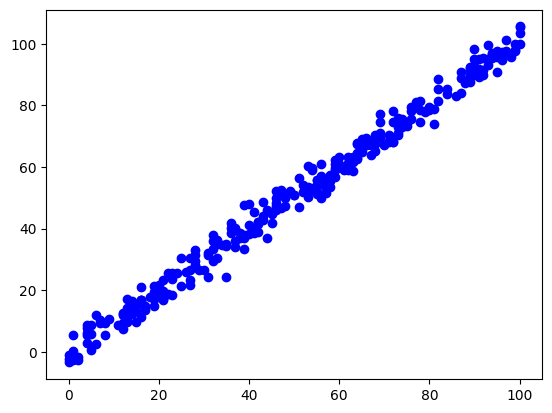

In [11]:
plt.scatter(x,y,c='b')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x_train.shape,x_test.shape

((240,), (60,))

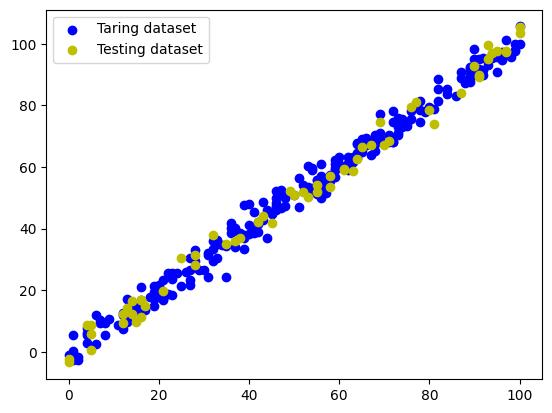

In [14]:
plt.scatter(x_train,y_train,c='b', label='Taring dataset')
plt.scatter(x_test,y_test,c='y', label='Testing dataset')
plt.legend()
plt.show()

#Model building


In [71]:
#create model
model=tf.keras.Sequential([
    tf.keras.layers.Dense(64,input_shape=(1,)),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#compile model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.05),
              metrics =['mae'])

#train model
epoch_number = 10
history = model.fit(tf.expand_dims(x_train,axis=1),y_train,epochs=epoch_number)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 32.4204 - mae: 32.4204
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.1528 - mae: 9.1528   
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4399 - mae: 6.4399 
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.1924 - mae: 4.1924 
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.4247 - mae: 3.4247 
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6703 - mae: 2.6703 
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9823 - mae: 2.9823 
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2322 - mae: 3.2322 
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.5845 - mae: 2.5845 
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7371 - mae: 2.7371 


In [72]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,369 (9.26 KB)

 Trainable params: 789 (3.08 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,580 (6.18 KB)

In [73]:
y_predictions= model.predict(x_test)
y_predictions[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[91.28104 ],
       [77.03982 ],
       [95.34996 ],
       [ 4.816457],
       [92.29827 ]], dtype=float32)

In [74]:
y_test.head()

,y
203,92.887723
266,79.503415
152,97.001484
9,8.746748
233,89.739520


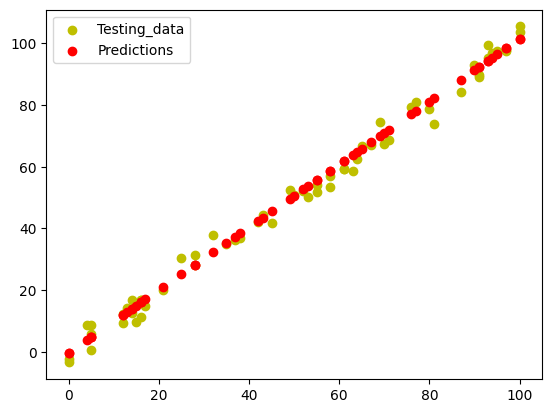

In [75]:
#plt.scatter(x_train, y_train, c='b', label='Training_data')
plt.scatter(x_test, y_test, c='y', label='Testing_data')
plt.scatter(x_test, y_predictions, c='r', label='Predictions')
plt.legend()
plt.show()

In [76]:
model.evaluate(x_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 2.5579 - mae: 2.5579 


[2.557924509048462, 2.557924509048462]

In [77]:
#using MAE
mae = tf.keras.losses.mae(y_test,tf.squeeze(y_predictions))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=2.5579237937927246>

In [78]:
#using mse
mse = tf.keras.losses.mse(y_test,tf.squeeze(y_predictions))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=9.486785888671875>

In [79]:
history.history

{'loss': [32.42043685913086,
  9.15279769897461,
  6.439881324768066,
  4.192426681518555,
  3.424741506576538,
  2.6703333854675293,
  2.9822964668273926,
  3.232189893722534,
  2.5845370292663574,
  2.7371115684509277],
 'mae': [32.42043685913086,
  9.15279769897461,
  6.439881324768066,
  4.192426681518555,
  3.424741506576538,
  2.6703333854675293,
  2.9822964668273926,
  3.232189893722534,
  2.5845370292663574,
  2.7371115684509277]}

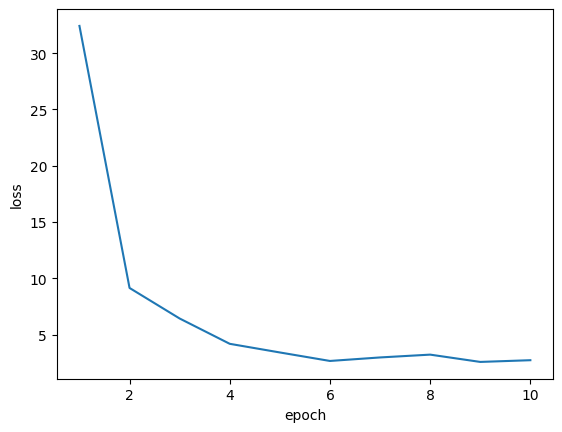

In [80]:
x_range = range(1, epoch_number + 1)
loss = history.history['loss']

plt.plot(x_range, loss)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [81]:
for layer in model.layers:
    weights = layer.get_weights()[0]
    biases = layer.get_weights()[1]
    print(f"\nWeights:\n {weights} \nBiases:\n {biases}")


Weights:
 [[-1.05166407e-02  4.12468724e-02 -1.18565433e-01  2.04895779e-01
  -1.31806463e-01 -1.75734679e-03 -2.14711607e-01  8.23241249e-02
  -1.97735354e-01 -8.08423292e-03  7.23584672e-04 -1.13256402e-01
   4.73179892e-02 -1.27896145e-02  4.77527827e-03  2.90728780e-03
  -1.48773849e-01 -1.11773293e-02 -4.42130454e-02 -6.94199353e-02
  -1.07628377e-02  2.13149965e-01 -1.04212295e-02  1.07302085e-01
   3.51416282e-02  2.36869492e-02 -7.44063454e-03 -2.63902068e-01
   2.94608504e-01 -1.07534014e-01  1.92964207e-02 -8.26994106e-02
   4.93144663e-03 -2.92476788e-02 -4.89240466e-03 -2.68302672e-03
  -2.53254443e-01 -4.44559334e-03 -1.06404535e-01 -3.09704933e-02
   1.85670927e-02 -9.12982784e-03 -1.16343051e-01 -3.17942840e-03
  -7.99773261e-06  4.40470269e-03  6.40299469e-02 -3.22948515e-01
  -8.79319292e-03  7.98808336e-02  6.11321405e-02  6.99597150e-02
   1.29440362e-02 -1.39145050e-02  2.75378942e-01 -4.22286093e-02
   1.93147827e-02 -2.02420522e-02  3.91345397e-02 -4.06593867e-02